# 04 — Segmentation of Hidden Entrepreneurs

**Задача:** KMeans k=5 на найденных hidden entrepreneurs → профили сегментов → бизнес-названия.

**Пайплайн:**
1. Загрузка `consumer_scored.parquet`, отбор top-6% по score
2. StandardScaler → KMeans(k=5)
3. Профили сегментов (медианы фичей)
4. Radar chart + Bar chart + PCA scatter
5. ROI-расчёт

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.segmentation.cluster import (
    fit_kmeans, build_segment_profiles,
    plot_segment_radar, plot_segment_bars, plot_pca_scatter,
)
from src.config import (
    PROCESSED_DIR, MODELS_DIR, RANDOM_STATE,
    N_SEGMENTS, SEGMENT_NAMES, HIDDEN_ENTREPRENEUR_SHARE,
    CONVERSION_RATE, LTV_PER_CLIENT_KZT,
)

## 1. Загрузка и отбор top-6% hidden entrepreneurs

In [2]:
scored = pl.read_parquet(PROCESSED_DIR / "consumer_scored.parquet").to_pandas()
print(f"Loaded: {scored.shape[0]:,} consumer cards, {scored.shape[1]} columns")

# Отбираем top-6% по business_score
n_hidden = int(len(scored) * HIDDEN_ENTREPRENEUR_SHARE)
threshold = float(sorted(scored["business_score"].values, reverse=True)[n_hidden])
hidden = scored[scored["business_score"] >= threshold].copy().reset_index(drop=True)
print(f"Top-{HIDDEN_ENTREPRENEUR_SHARE*100:.0f}% threshold: {threshold:.6f}")
print(f"Hidden entrepreneurs: {len(hidden):,} cards")

# Фичи для кластеризации (всё кроме card_number и business_score)
feature_cols = [c for c in hidden.columns if c not in ("card_number", "business_score")]
X = hidden[feature_cols]
print(f"Features for clustering: {len(feature_cols)}")

Loaded: 80,000 consumer cards, 65 columns
Top-6% threshold: 0.000010
Hidden entrepreneurs: 4,801 cards
Features for clustering: 63


## 2. KMeans k=5

In [3]:
kmeans_model, labels, scaler = fit_kmeans(X, n_clusters=N_SEGMENTS)

hidden["segment"] = labels
hidden["segment_name"] = [SEGMENT_NAMES.get(l, f"Segment {l}") for l in labels]

counts = hidden["segment_name"].value_counts()
print("Segment sizes:")
for seg, cnt in counts.items():
    print(f"  {seg}: {cnt:,} cards ({cnt/len(hidden)*100:.1f}%)")

Segment sizes:
  Digital / IT: 2,563 cards (53.4%)
  Offline retail: 866 cards (18.0%)
  Service providers: 562 cards (11.7%)
  Restauranteurs: 436 cards (9.1%)
  E-commerce sellers: 374 cards (7.8%)


## 3. Профили сегментов (ключевые фичи)

In [4]:
# Ключевые фичи для профилирования (интерпретируемые бизнесом)
PROFILE_FEATURES = [
    "b2b_spend_share",
    "foreign_tx_share",
    "online_share",
    "recurring_amount_share",
    "business_hours_share",
    "weekend_share",
    "rental_tx_share",
    "tokenized_share",
    "merchant_hhi",
    "business_merchant_overlap",
]

profiles = build_segment_profiles(hidden, labels, PROFILE_FEATURES)
print("Segment profiles (median):")
print(profiles.T.to_string())

Segment profiles (median):
                           E-commerce sellers  Offline retail  Service providers  Restauranteurs  Digital / IT
b2b_spend_share                        0.0124          0.9954             0.7827          0.2827        0.1118
foreign_tx_share                       1.0000          1.0000             1.0000          1.0000        1.0000
online_share                           0.4513          0.8454             0.6247          0.8398        0.4355
recurring_amount_share                 0.0010          0.2178             0.1308          0.0000        0.0155
business_hours_share                   0.3569          0.5566             0.3077          0.7105        0.3333
weekend_share                          0.3411          0.1275             0.3425          0.0909        0.3514
rental_tx_share                        0.0649          0.0000             0.0000          0.0000        0.0078
tokenized_share                        0.3827          0.3151             0.3704     

## 4. Визуализация: Radar, Bar, PCA

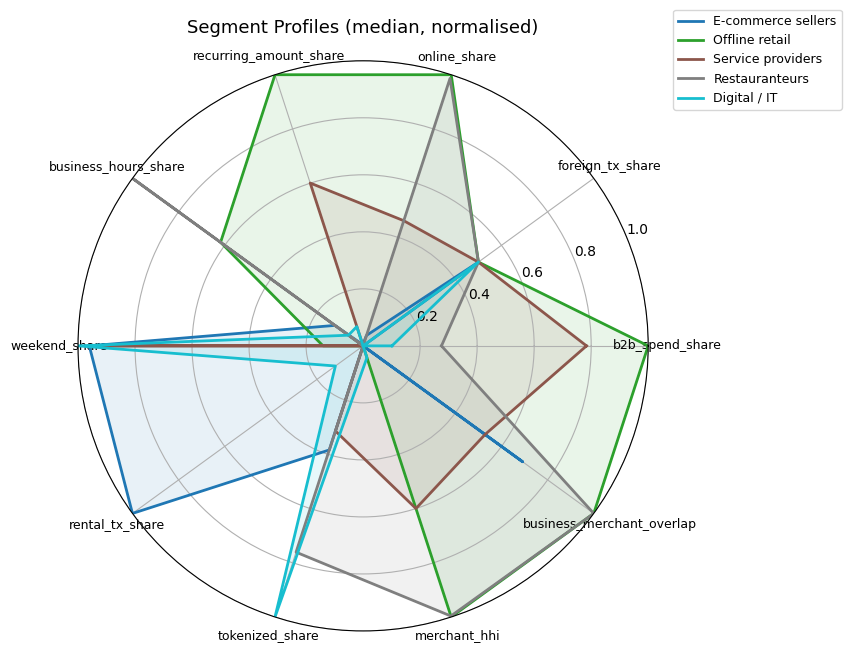

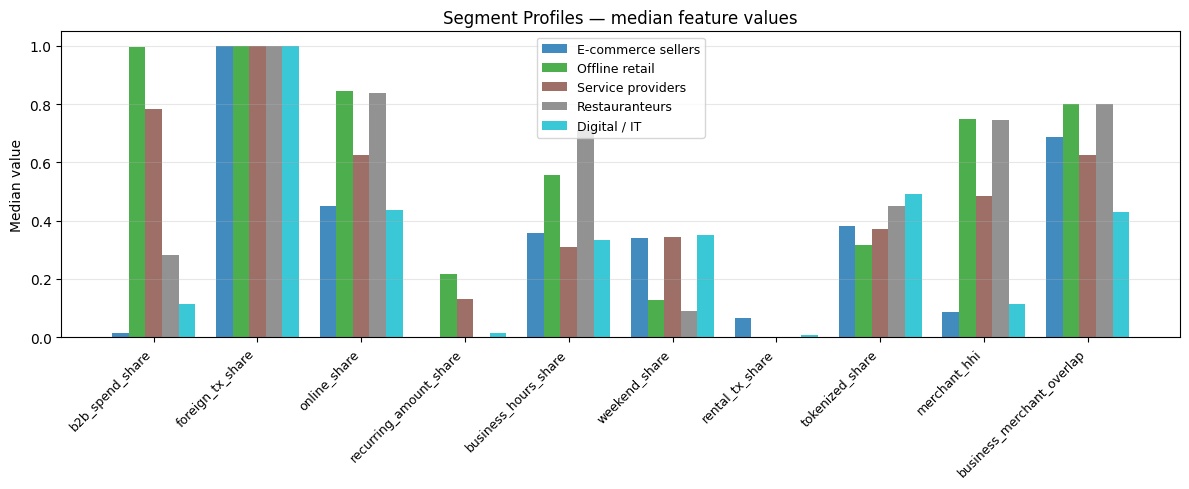

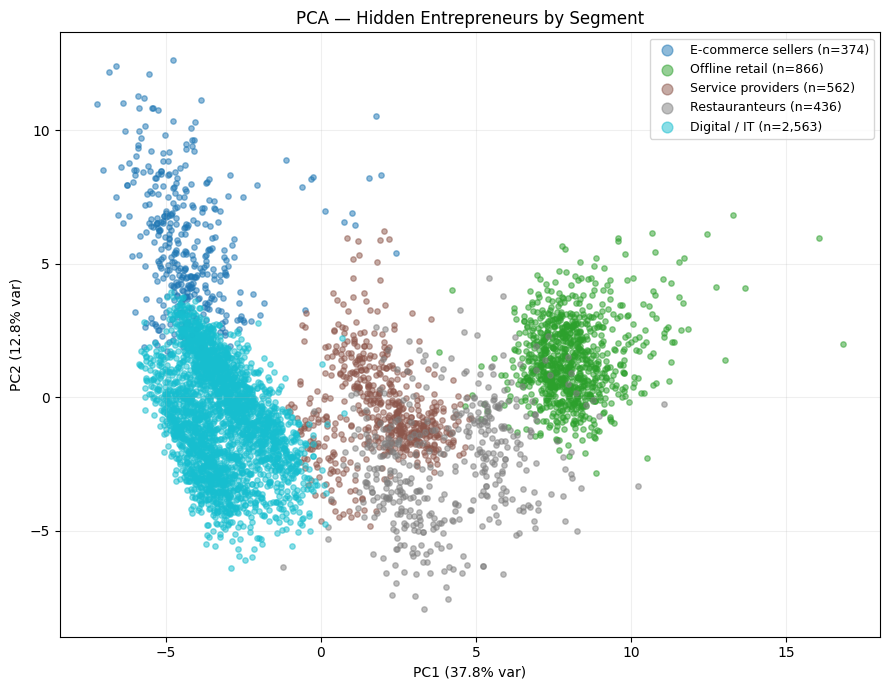

In [5]:
fig = plot_segment_radar(profiles, PROFILE_FEATURES)
plt.show()

fig = plot_segment_bars(profiles, PROFILE_FEATURES)
plt.show()

fig = plot_pca_scatter(X, labels, scaler)
plt.show()

## 5. Бизнес-профили сегментов

In [6]:
# Расширенный профиль: топ-5 отличительных фичей каждого сегмента
all_profiles = build_segment_profiles(hidden, labels, feature_cols)

print("=== Топ-5 фичей с наибольшим отклонением от медианы всей выборки ===\n")
global_median = X[feature_cols].median()

for seg_name in all_profiles.index:
    diff = (all_profiles.loc[seg_name] - global_median).abs().sort_values(ascending=False)
    top5 = diff.head(5)
    print(f"[{seg_name}]")
    for feat, delta in top5.items():
        seg_val = all_profiles.loc[seg_name, feat]
        glob_val = global_median[feat]
        direction = "↑" if seg_val > glob_val else "↓"
        print(f"  {direction} {feat}: {seg_val:.3f}  (global={glob_val:.3f})")
    print()

=== Топ-5 фичей с наибольшим отклонением от медианы всей выборки ===

[E-commerce sellers]
  ↑ total_spend_kzt: 18158030.500  (global=3754763.000)
  ↑ max_daily_spend_kzt: 1775270.500  (global=497702.000)
  ↑ max_ticket_kzt: 1567836.500  (global=455965.000)
  ↑ p95_ticket_kzt: 404589.500  (global=163630.000)
  ↑ std_ticket_kzt: 202781.704  (global=74006.915)

[Offline retail]
  ↑ total_spend_kzt: 23760120.000  (global=3754763.000)
  ↑ max_daily_spend_kzt: 2481624.500  (global=497702.000)
  ↑ max_ticket_kzt: 2292060.500  (global=455965.000)
  ↑ p95_ticket_kzt: 895486.500  (global=163630.000)
  ↑ std_ticket_kzt: 389925.047  (global=74006.915)

[Service providers]
  ↑ total_spend_kzt: 4102361.000  (global=3754763.000)
  ↓ max_daily_spend_kzt: 384987.500  (global=497702.000)
  ↓ max_ticket_kzt: 365709.500  (global=455965.000)
  ↑ p95_ticket_kzt: 179076.000  (global=163630.000)
  ↑ avg_ticket_kzt: 55732.953  (global=45912.562)

[Restauranteurs]
  ↑ total_spend_kzt: 12081962.500  (global=375

## 6. ROI-расчёт

In [7]:
n_candidates = len(hidden)
n_converted = int(n_candidates * CONVERSION_RATE)
total_ltv = n_converted * LTV_PER_CLIENT_KZT

print("=== ROI Assessment ===")
print(f"Hidden entrepreneur candidates: {n_candidates:,}")
print(f"Conversion rate assumption:     {CONVERSION_RATE*100:.0f}%")
print(f"Converted to business clients:  {n_converted:,}")
print(f"LTV per client (annual):        {LTV_PER_CLIENT_KZT:,} ₸")
print(f"Total incremental revenue:      {total_ltv:,} ₸  ({total_ltv/1_000_000:.1f}M ₸)")
print()
print("Per segment:")
for seg_name, cnt in counts.items():
    seg_converted = int(cnt * CONVERSION_RATE)
    seg_ltv = seg_converted * LTV_PER_CLIENT_KZT
    print(f"  {seg_name}: {cnt:,} candidates → {seg_converted:,} converted → {seg_ltv/1_000_000:.1f}M ₸")

=== ROI Assessment ===
Hidden entrepreneur candidates: 4,801
Conversion rate assumption:     15%
Converted to business clients:  720
LTV per client (annual):        200,000 ₸
Total incremental revenue:      144,000,000 ₸  (144.0M ₸)

Per segment:
  Digital / IT: 2,563 candidates → 384 converted → 76.8M ₸
  Offline retail: 866 candidates → 129 converted → 25.8M ₸
  Service providers: 562 candidates → 84 converted → 16.8M ₸
  Restauranteurs: 436 candidates → 65 converted → 13.0M ₸
  E-commerce sellers: 374 candidates → 56 converted → 11.2M ₸


## 7. Сохранение результатов

In [ ]:
segments_path = PROCESSED_DIR / "segments.parquet"
pl.from_pandas(
    hidden[["card_number", "business_score", "segment", "segment_name"]]
).write_parquet(segments_path)
print(f"Saved → {segments_path}")
print(f"\nDone. {len(hidden):,} hidden entrepreneurs in {N_SEGMENTS} segments.")
print("Next: FINAL_pipeline.ipynb")